In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

In [2]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),   # 随机裁剪
    transforms.RandomHorizontalFlip(),      # 随机水平翻转
    transforms.ToTensor(),                  # 转为张量
    transforms.Normalize((0.4914, 0.4822, 0.4465),  # 用 CIFAR-10 的真实均值
                         (0.2023, 0.1994, 0.2010))   # 用 CIFAR-10 的真实标准差
])

transform_test =transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), 
                         (0.2023, 0.1994, 0.2010))
])

In [3]:
batch_size = 128

trainset = torchvision.datasets.CIFAR10(
    root='./data/cifar-10-python', train=True, download=False, transform=transform_train
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, num_workers=0
)

testset = torchvision.datasets.CIFAR10(
    root='./data/cifar-10-python', train=False, download=False, transform=transform_test
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=batch_size, shuffle=False, num_workers=0
)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

In [4]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)    # 输入3通道，输出32通道，卷积核3x3
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)                 # 2x2 最大池化
        self.dropout1 = nn.Dropout(0.25)               # 随机丢弃 25% 的神经元
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)         # 全连接层
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 卷积 -> ReLU -> 池化
        x = self.dropout1(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout1(x)
        x = self.pool(F.relu(self.conv3(x)))
        x = self.dropout1(x)
        x = x.view(-1, 128 * 4 * 4)            # 展平成一维
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

net = Net()
print(net)   # 打印网络结构，确认无误

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = net.to(device)   # 将模型参数搬到 GPU 上

criterion = nn.CrossEntropyLoss()  # 交叉熵损失函数
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()  # 切换到训练模式（启用 Dropout）
    running_loss = 0.0
    correct = 0
    total = 0
    loop = tqdm(loader, desc='Training')  # 包装进度条
    for inputs, targets in loop:
        inputs, targets = inputs.to(device), targets.to(device)  # 数据也搬到 GPU

        optimizer.zero_grad()          # 清空上一步的梯度
        outputs = model(inputs)        # 前向传播
        loss = criterion(outputs, targets)  # 计算损失
        loss.backward()                # 反向传播，计算梯度
        optimizer.step()               # 更新参数

        # 统计本批次的损失和准确率
        running_loss += loss.item()
        _, predicted = outputs.max(1)  # 取每一行最大值的索引（即预测类别）
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        # 在进度条上实时显示当前 loss 和准确率
        loop.set_postfix(loss=loss.item(), acc=100.*correct/total)

    return running_loss / len(loader), 100.*correct/total

In [7]:
def test(model, loader, criterion):
    model.eval()   # 切换到评估模式（关闭 Dropout）
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():  # 关闭梯度计算，节省显存和计算
        for inputs, targets in tqdm(loader, desc='Testing'):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return test_loss / len(loader), 100.*correct/total

In [8]:
num_epochs = 30          # 对整个训练集迭代 30 次
best_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(net, trainloader, criterion, optimizer)
    val_loss, val_acc = test(net, testloader, criterion)

    # 更新学习率
    scheduler.step(val_loss)

    # 保存效果最好的模型
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(net.state_dict(), 'best_model.pth')

    print(f'Epoch {epoch+1:02d}: Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.3f} | Val Acc: {val_acc:.2f}% | Best: {best_acc:.2f}%')

print('Finished Training!')

Testing: 100%|██████████| 79/79 [00:00<00:00, 102.30it/s]


Epoch 01: Train Loss: 2.121 | Train Acc: 19.53% | Val Loss: 1.852 | Val Acc: 30.83% | Best: 30.83%


Testing: 100%|██████████| 79/79 [00:00<00:00, 105.15it/s]


Epoch 02: Train Loss: 1.804 | Train Acc: 31.74% | Val Loss: 1.575 | Val Acc: 42.42% | Best: 42.42%


Testing: 100%|██████████| 79/79 [00:00<00:00, 103.11it/s]


...

Epoch 28: Train Loss: 0.837 | Train Acc: 71.69% | Val Loss: 0.637 | Val Acc: 78.04% | Best: 78.04%


Testing: 100%|██████████| 79/79 [00:00<00:00, 101.81it/s]


Epoch 29: Train Loss: 0.828 | Train Acc: 71.89% | Val Loss: 0.638 | Val Acc: 77.87% | Best: 78.04%


Testing: 100%|██████████| 79/79 [00:00<00:00, 100.28it/s]

Epoch 30: Train Loss: 0.821 | Train Acc: 71.97% | Val Loss: 0.641 | Val Acc: 77.56% | Best: 78.04%
Finished Training!


共找到 3 张图片
15020C406-1.jpg -> 预测类别：plane（置信度 76.42%）


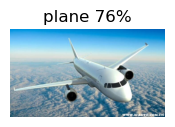

OIP-C.jpg -> 预测类别：plane（置信度 62.80%）


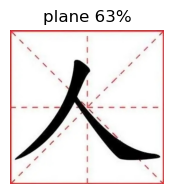

cf1b9d16fdfaaf51f3dec5bd8a0283eef01f3a29cc21.jpg -> 预测类别：dog（置信度 60.52%）


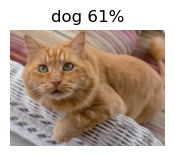

In [13]:
from PIL import Image
import glob, os
import matplotlib.pyplot as plt

# 加载之前保存的最佳模型参数
net.load_state_dict(torch.load('best_model.pth'))
net = net.to(device)
net.eval()

# 定义与测试时一样的预处理（不包含数据增强）
predict_transform = transforms.Compose([
    transforms.Resize((32, 32)),   # 将图片缩放到 32x32
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# 把要测试的图片放进 test_images 文件夹（jpg/jpeg/png，可放多张）
image_dir = 'test_images'
image_files = sorted(
    glob.glob(os.path.join(image_dir, '*.jpg')) +
    glob.glob(os.path.join(image_dir, '*.jpeg')) +
    glob.glob(os.path.join(image_dir, '*.png'))
)
print(f'共找到 {len(image_files)} 张图片')

for img_path in image_files:
    image = Image.open(img_path).convert('RGB')           # 确保是三通道彩色图
    x = predict_transform(image).unsqueeze(0).to(device)  # 形状变为 (1,3,32,32)

    with torch.no_grad():
        output = net(x)                                   # 前向传播，输出各类分数
        prob = torch.softmax(output, dim=1)[0]
        pred = output.argmax(1).item()
    print(f'{os.path.basename(img_path)} -> 预测类别：{classes[pred]}（置信度 {prob[pred].item():.2%}）')

    # 在 notebook 里显示这张图片（可选）
    plt.figure(figsize=(2, 2))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'{classes[pred]} {prob[pred].item():.0%}')
    plt.show()